# Fraud Detection with Financial Transactions


---
### Notebook Structure
1. Setup & Imports
2. Load Data
3. Data Integrity Check
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Network / Graph Features 
7. Data Encoding
8. Sampling & Class Imbalance (SMOTENC) 
9. Evaluation Function
10. Baseline Model — Logistic Regression
11. Ablation Study *(EXTENDED: raw / engineered / +network)*
12. Model Training — Random Forest & Gradient Boosting
13. 5-Fold Cross-Validation 
14. Precision-Recall & ROC Curves
15. Threshold Optimisation
16. Cost-Sensitive Analysis
17. SHAP Feature Importance
18. Temporal Validation
19. Concept Drift Simulation 
20. Final Model Comparison

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc,
    roc_curve, f1_score, average_precision_score
)


from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load Data

In [2]:
!pip install gdown


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import gdown
import os

# Download dataset from Google Drive if not already present
FILE_ID = '1ftzoJuo8JX1JiOaeLzBN_eiH-VIr8qmQ'
path = 'Fraud.csv'

if not os.path.exists(path):
    print('Downloading Fraud.csv from Google Drive...')
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', path, quiet=False)
    print('Download complete.')
else:
    print('Dataset already exists locally, skipping download.')

Dataset already exists locally, skipping download.


          fraud_cases    total  fraud_rate_%
type                                        
CASH_OUT         4116  2237500          0.18
TRANSFER         4097   532909          0.77
CASH_IN             0  1399284          0.00
DEBIT               0    41432          0.00
PAYMENT             0  2151495          0.00


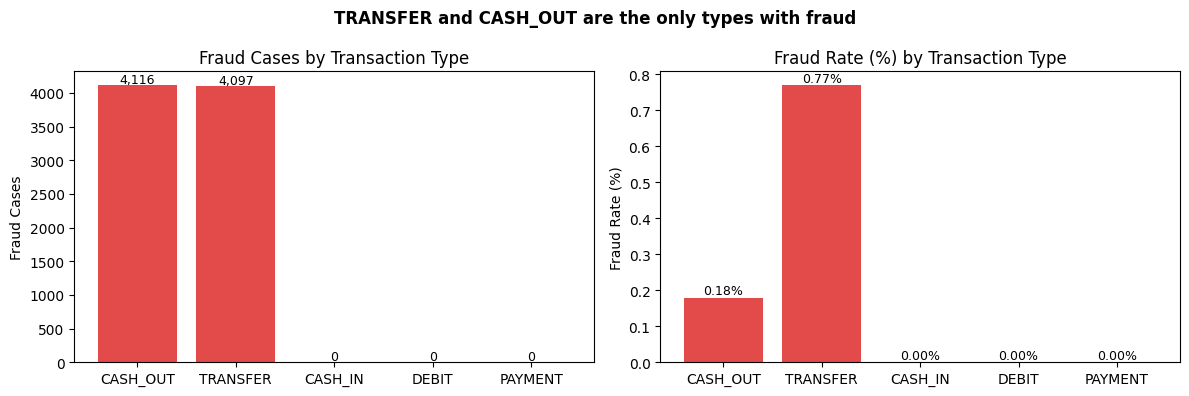

In [4]:

df_full = pd.read_csv(path, usecols=['type', 'isFraud'])

# Fraud count and rate per type
summary = df_full.groupby('type')['isFraud'].agg(['sum', 'count'])
summary.columns = ['fraud_cases', 'total']
summary['fraud_rate_%'] = (summary['fraud_cases'] / summary['total'] * 100).round(2)
summary = summary.sort_values('fraud_cases', ascending=False)
print(summary)
del df_full

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#E24B4A' if t in ['TRANSFER','CASH_OUT'] else '#cccccc' for t in summary.index]

axes[0].bar(summary.index, summary['fraud_cases'], color=colors)
axes[0].set_title('Fraud Cases by Transaction Type')
axes[0].set_ylabel('Fraud Cases')
for i, v in enumerate(summary['fraud_cases']):
    axes[0].text(i, v + 30, f'{int(v):,}', ha='center', fontsize=9)

axes[1].bar(summary.index, summary['fraud_rate_%'], color=colors)
axes[1].set_title('Fraud Rate (%) by Transaction Type')
axes[1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(summary['fraud_rate_%']):
    axes[1].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=9)

plt.suptitle('TRANSFER and CASH_OUT are the only types with fraud', fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# Keep nameOrig and nameDest for graph feature extraction
# They will be dropped after network features are computed
cols = ['step', 'type', 'amount', 'nameOrig', 'nameDest',
        'oldbalanceOrg', 'newbalanceOrig',
        'oldbalanceDest', 'newbalanceDest', 'isFraud']

# Process chunk by chunk instead of loading all into memory at once
filtered_chunks = []
for chunk in pd.read_csv(path, usecols=cols, chunksize=100000):  # smaller chunks
    filtered = chunk[(chunk['type'] == 'TRANSFER') | (chunk['type'] == 'CASH_OUT')]
    # Downcast immediately per chunk to free memory
    for col in ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']:
        filtered[col] = pd.to_numeric(filtered[col], downcast='float')
    filtered_chunks.append(filtered)

df = pd.concat(filtered_chunks, ignore_index=True)
del filtered_chunks  # free memory

print(f'Filtered Dataset Size: {df.shape}')
df.head()

Filtered Dataset Size: (2770409, 10)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1
1,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1
2,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0
3,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0
4,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0


In [6]:
# Save filtered dataset
save_path = r'C:\Users\niumi\Desktop\BDA\LEVEL 06\Final Year Project\Final Submission\dataset\Fraud_filtered.csv'
df.to_csv(save_path, index=False)
print(f'Filtered dataset saved! Shape: {df.shape}')

Filtered dataset saved! Shape: (2770409, 10)


## 3. Data Integrity Check

In [7]:
print('--- Null Values ---')
print(df.isnull().sum())

print(f'\n--- Duplicate Rows: {df.duplicated().sum()} ---')

print('\n--- Class Distribution ---')
print(df['isFraud'].value_counts())
print(f'Fraud Rate: {df["isFraud"].mean()*100:.4f}%')

--- Null Values ---
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

--- Duplicate Rows: 0 ---

--- Class Distribution ---
isFraud
0    2762196
1       8213
Name: count, dtype: int64
Fraud Rate: 0.2965%


## 4. Exploratory Data Analysis (EDA)

> EDA is performed on raw filtered data before feature engineering.

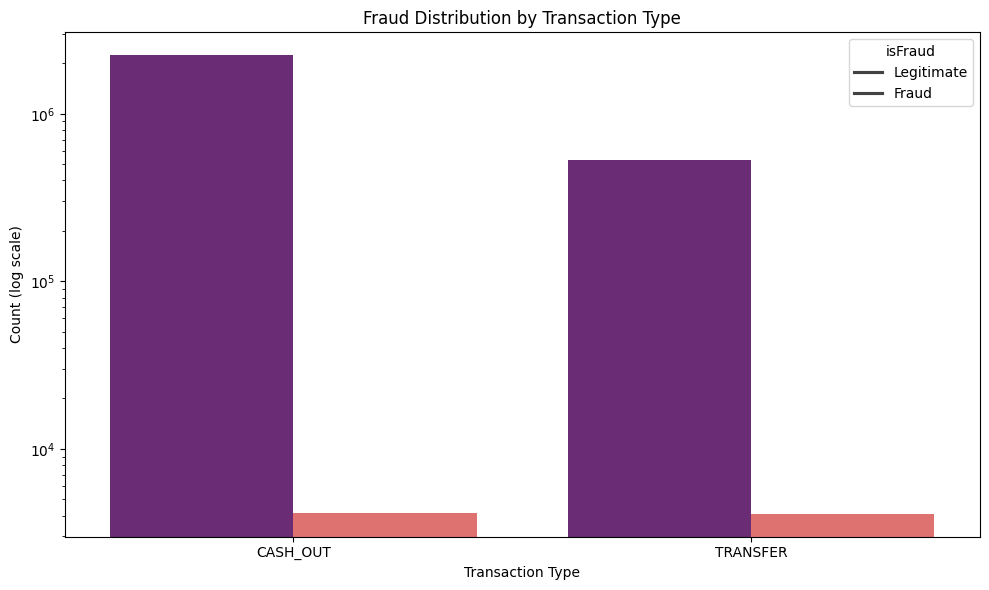

In [8]:
# EDA 1: Fraud Distribution by Transaction Type
counts = df.groupby(['type', 'isFraud']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))
sns.barplot(x='type', y='count', hue='isFraud', data=counts, palette='magma')
plt.title('Fraud Distribution by Transaction Type')
plt.yscale('log')
plt.xlabel('Transaction Type')
plt.ylabel('Count (log scale)')
plt.legend(title='isFraud', labels=['Legitimate', 'Fraud'])
plt.tight_layout()
plt.show()

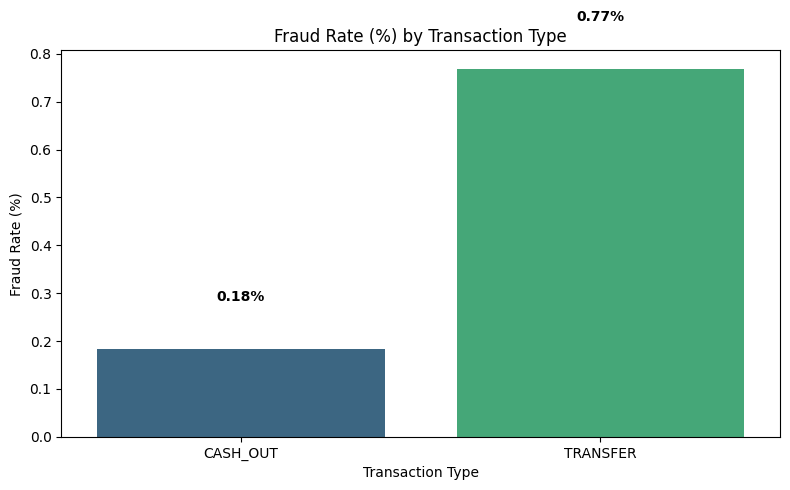

In [9]:
# EDA 2: Fraud Rate by Transaction Type
fraud_rate = df.groupby('type')['isFraud'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=fraud_rate.index, y=fraud_rate.values, palette='viridis')
plt.title('Fraud Rate (%) by Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('Transaction Type')
for i, v in enumerate(fraud_rate.values):
    plt.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

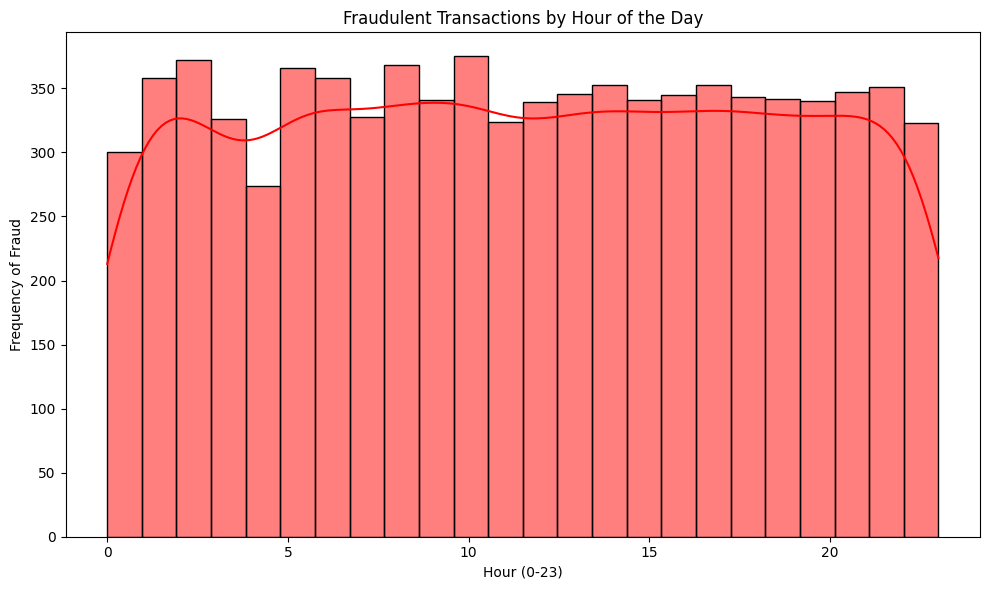

In [10]:
# EDA 3: Temporal Analysis (Fraud by Hour)
hour_temp = df['step'] % 24
fraud_hours = hour_temp[df['isFraud'] == 1]

plt.figure(figsize=(10, 6))
sns.histplot(fraud_hours, bins=24, kde=True, color='red')
plt.title('Fraudulent Transactions by Hour of the Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Frequency of Fraud')
plt.tight_layout()
plt.show()

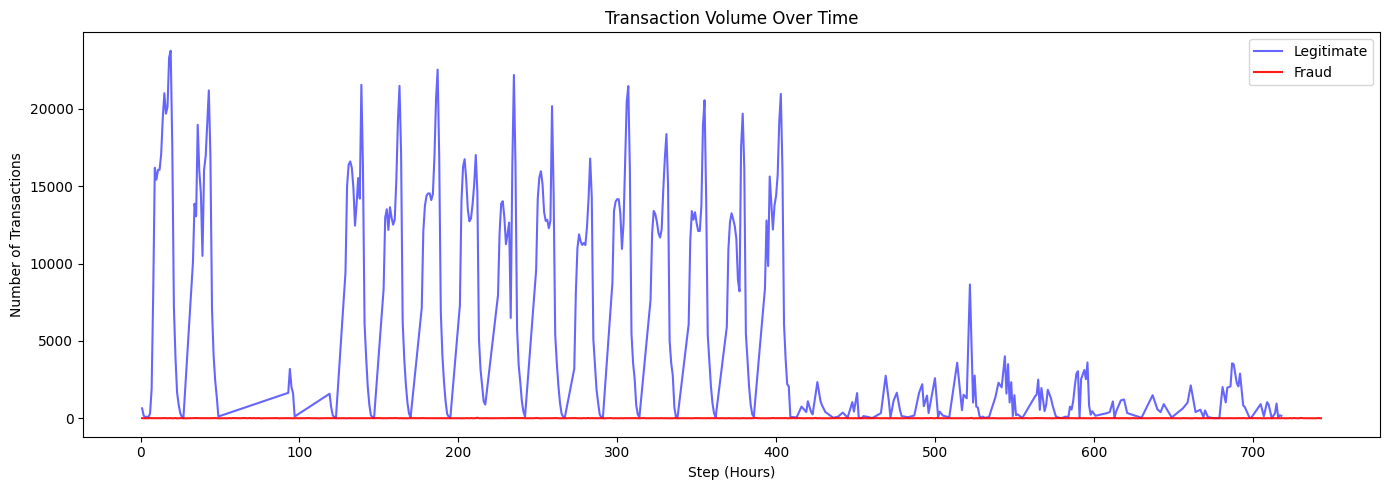

In [11]:
# EDA 4: Fraud Volume Over Time
plt.figure(figsize=(14, 5))
fraud_by_step = df[df['isFraud'] == 1].groupby('step').size()
legit_by_step = df[df['isFraud'] == 0].groupby('step').size()

plt.plot(legit_by_step.index, legit_by_step.values, label='Legitimate', alpha=0.6, color='blue')
plt.plot(fraud_by_step.index, fraud_by_step.values, label='Fraud', alpha=0.9, color='red')
plt.title('Transaction Volume Over Time')
plt.xlabel('Step (Hours)')
plt.ylabel('Number of Transactions')
plt.legend()
plt.tight_layout()
plt.show()

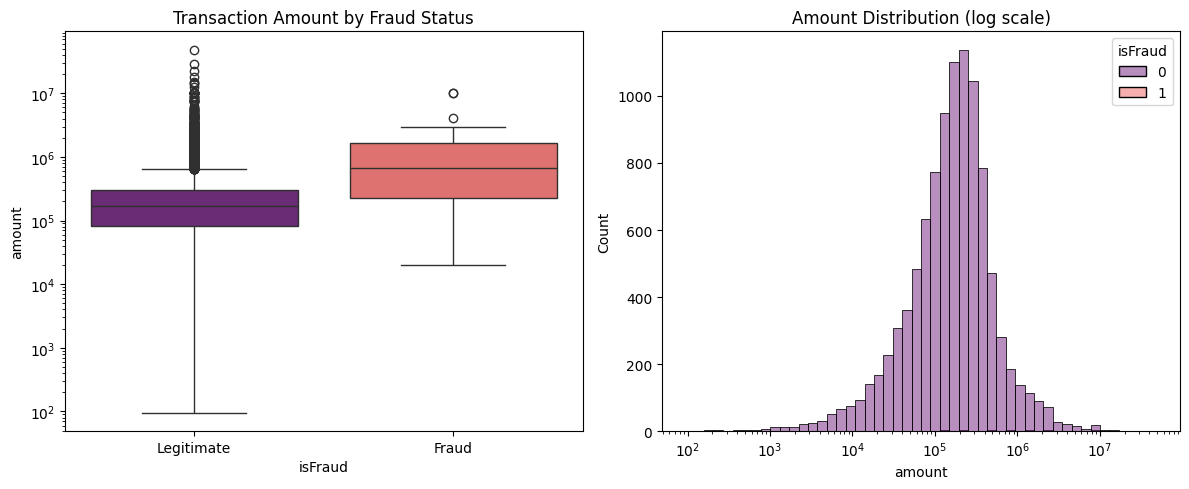

In [12]:
# EDA 5: Amount Distribution by Fraud Status
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='isFraud', y='amount', data=df.sample(10000, random_state=42), palette='magma')
plt.title('Transaction Amount by Fraud Status')
plt.yscale('log')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])

plt.subplot(1, 2, 2)
sns.histplot(data=df.sample(10000, random_state=42), x='amount', hue='isFraud',
             bins=50, log_scale=True, palette='magma')
plt.title('Amount Distribution (log scale)')
plt.tight_layout()
plt.show()

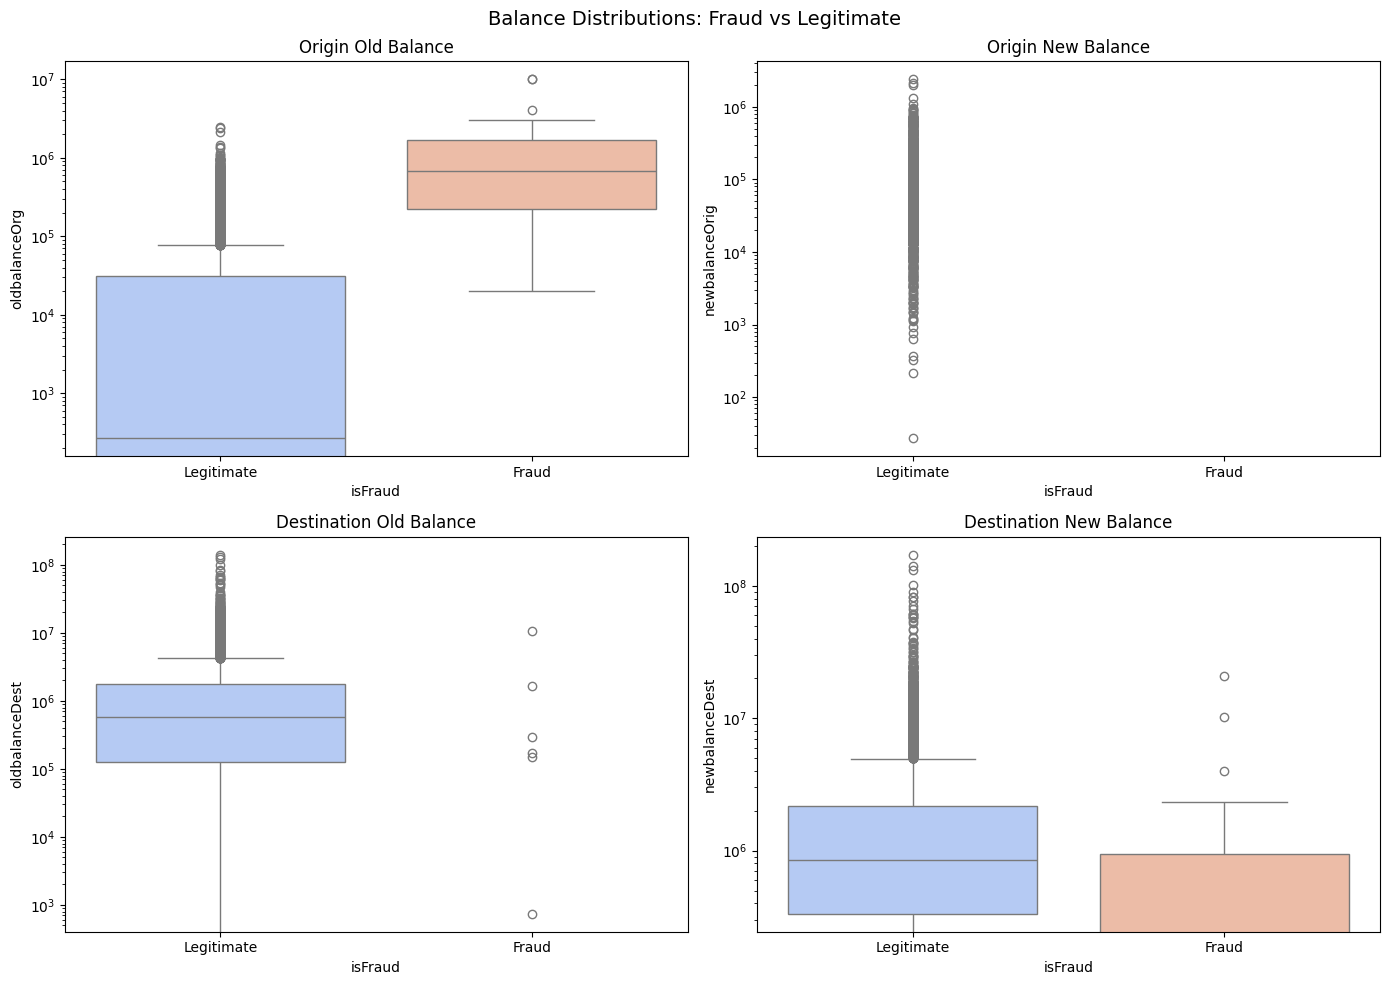

In [13]:
# EDA 6: Balance Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sample = df.sample(10000, random_state=42)

for ax, col, title in zip(
    axes.flatten(),
    ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'],
    ['Origin Old Balance', 'Origin New Balance', 'Destination Old Balance', 'Destination New Balance']
):
    sns.boxplot(x='isFraud', y=col, data=sample, palette='coolwarm', ax=ax)
    ax.set_title(title)
    ax.set_yscale('log')
    ax.set_xticklabels(['Legitimate', 'Fraud'])

plt.suptitle('Balance Distributions: Fraud vs Legitimate', fontsize=14)
plt.tight_layout()
plt.show()

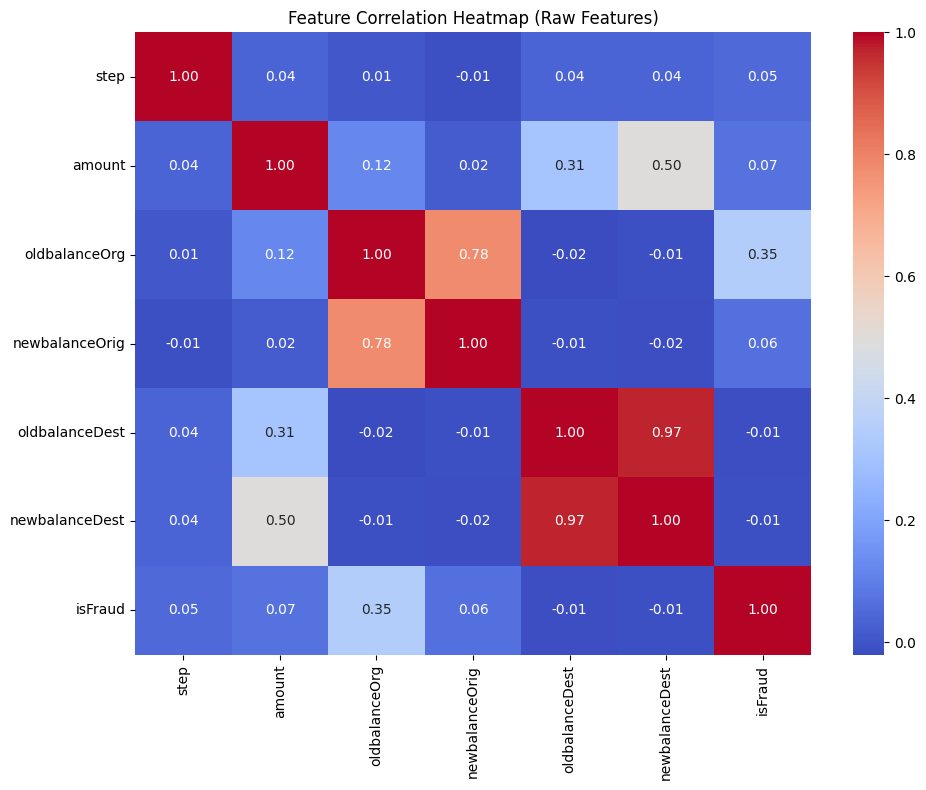

In [14]:
# EDA 7: Raw Correlation Heatmap
plt.figure(figsize=(10, 8))
raw_corr_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                 'oldbalanceDest', 'newbalanceDest', 'isFraud']
correlation = df[raw_corr_cols].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap (Raw Features)')
plt.tight_layout()
plt.show()

Total outliers by IQR: 223,100
Outlier fraud rate: 1.54%
Normal fraud rate:  0.19%


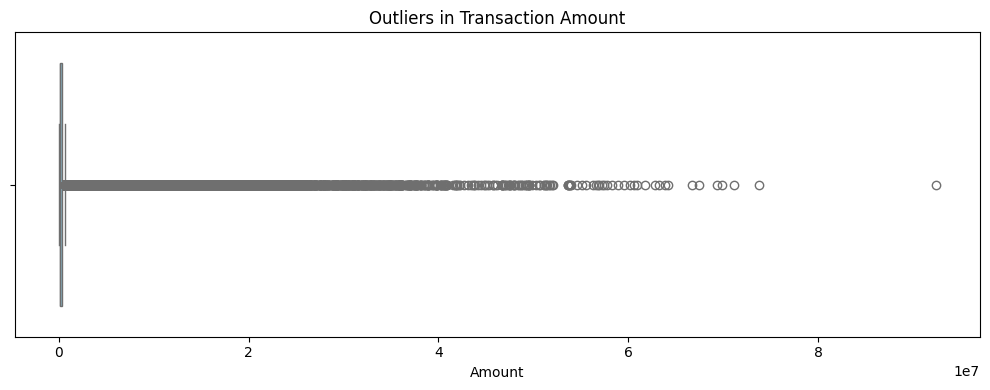

In [15]:
# EDA 8: Outlier Detection (IQR)
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['amount'] < lower) | (df['amount'] > upper)]
print(f'Total outliers by IQR: {len(outliers):,}')
print(f'Outlier fraud rate: {outliers["isFraud"].mean()*100:.2f}%')
print(f'Normal fraud rate:  {df[~df.index.isin(outliers.index)]["isFraud"].mean()*100:.2f}%')

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['amount'], color='skyblue')
plt.title('Outliers in Transaction Amount')
plt.xlabel('Amount')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

> Each feature is only created if the column does not already exist (idempotency fix).
> Six domain-informed features are engineered from raw transaction fields.

In [16]:
# Feature 1: Balance Discrepancy (Origin)
# Captures cases where the expected post-transaction balance doesn't match actual
if 'errorBalanceOrg' not in df.columns:
    df['errorBalanceOrg'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']

# Feature 2: Balance Discrepancy (Destination)
if 'errorBalanceDest' not in df.columns:
    df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# Feature 3: Time of Day
if 'hour' not in df.columns:
    df['hour'] = df['step'] % 24

# Feature 4: Zero Balance Flag (Binary)
if 'is_zero_balance_orig' not in df.columns:
    df['is_zero_balance_orig'] = (df['newbalanceOrig'] == 0).astype(int)

# Feature 5: Large Transaction Flag (Binary)
if 'is_large_transaction' not in df.columns:
    threshold = df['amount'].quantile(0.95)
    df['is_large_transaction'] = (df['amount'] > threshold).astype(int)

# Feature 6: Destination Zero Before (Binary)
if 'is_dest_zero_before' not in df.columns:
    df['is_dest_zero_before'] = (df['oldbalanceDest'] == 0).astype(int)

# Drop 'step' after extracting 'hour'
if 'step' in df.columns:
    df.drop('step', axis=1, inplace=True)

print('Feature engineering complete. Columns:', df.columns.tolist())

Feature engineering complete. Columns: ['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'errorBalanceOrg', 'errorBalanceDest', 'hour', 'is_zero_balance_orig', 'is_large_transaction', 'is_dest_zero_before']


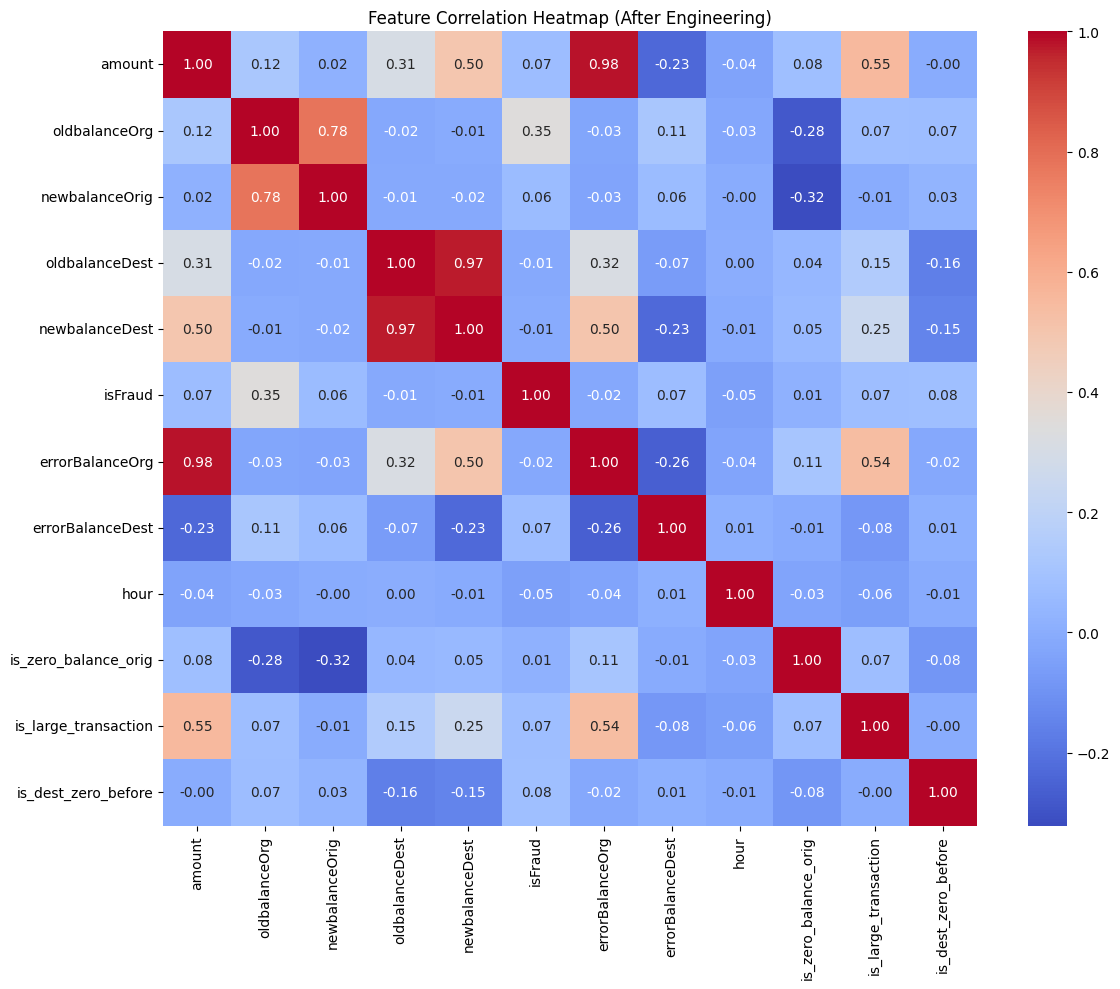

In [17]:
# Post-Engineering Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_eng = df.drop(columns=['type', 'nameOrig', 'nameDest'], errors='ignore').corr(numeric_only=True)
sns.heatmap(correlation_eng, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap (After Engineering)')
plt.tight_layout()
plt.show()

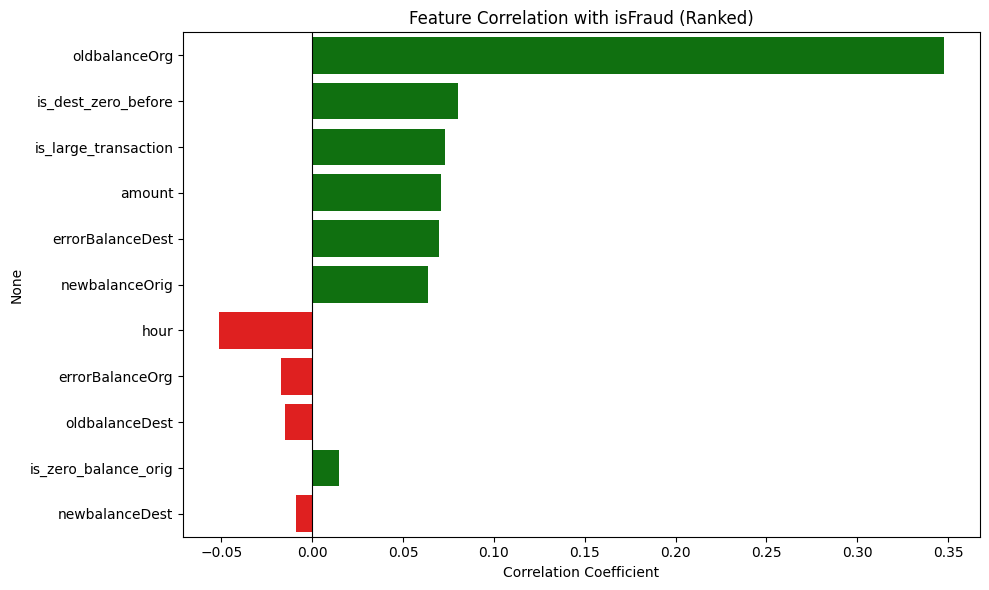


Top correlations with isFraud:
oldbalanceOrg           0.347582
is_dest_zero_before     0.080177
is_large_transaction    0.072878
amount                  0.070660
errorBalanceDest        0.069935
newbalanceOrig          0.063557
hour                   -0.051230
errorBalanceOrg        -0.017149
oldbalanceDest         -0.014960
is_zero_balance_orig    0.014496
newbalanceDest         -0.008978
Name: isFraud, dtype: float64


In [18]:
# Feature Correlation with isFraud Ranked
numeric_df = df.select_dtypes(include=[np.number])
corr_with_fraud = numeric_df.corr()['isFraud'].drop('isFraud').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in corr_with_fraud.values]
sns.barplot(x=corr_with_fraud.values, y=corr_with_fraud.index, palette=colors)
plt.title('Feature Correlation with isFraud (Ranked)')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nTop correlations with isFraud:')
print(corr_with_fraud)

## 6. Network / Graph Features 

> **Research contribution:** Most fraud detection studies drop account identifiers entirely.
> This section extracts network-level features from nameOrig and nameDest before removing them.
> These features capture the transaction graph structure -high-frequency destination accounts,
> historical fraud rates per account, and sender diversity -which are known fraud indicators


In [19]:
print('Extracting network/graph features from account identifiers...')

# Features 7, 9, 10 are computed here ,they do NOT use the isFraud label
# so there is no data leakage risk from computing them before the train/test split.

# Feature 7: How many times has this destination received a transaction?
# High frequency destinations may indicate money mule accounts
if 'dest_transaction_count' not in df.columns:
    df['dest_transaction_count'] = df.groupby('nameDest')['isFraud'].transform('count')

# Feature 9: Number of unique senders to this destination
# Many unique senders to one destination may indicate aggregation fraud
if 'dest_unique_senders' not in df.columns:
    df['dest_unique_senders'] = df.groupby('nameDest')['nameOrig'].transform('nunique')

# Feature 10: How many times has this origin account sent a transaction?
# Very high frequency senders may indicate automated fraud scripts
if 'orig_transaction_count' not in df.columns:
    df['orig_transaction_count'] = df.groupby('nameOrig')['isFraud'].transform('count')

# NOTE: dest_historical_fraud_rate (Feature 8) uses the isFraud label.
# It is computed AFTER the train/test split in Section 8 to prevent data leakage.

# Drop account ID columns — kept until after fraud rate is computed in Section 8
# nameOrig and nameDest are dropped in Section 8 after Feature 8 is computed.
print('Network features (no-leakage) added. Columns so far:')
print(df.columns.tolist())


Extracting network/graph features from account identifiers...
Network features (no-leakage) added. Columns so far:
['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'errorBalanceOrg', 'errorBalanceDest', 'hour', 'is_zero_balance_orig', 'is_large_transaction', 'is_dest_zero_before', 'dest_transaction_count', 'dest_unique_senders', 'orig_transaction_count']


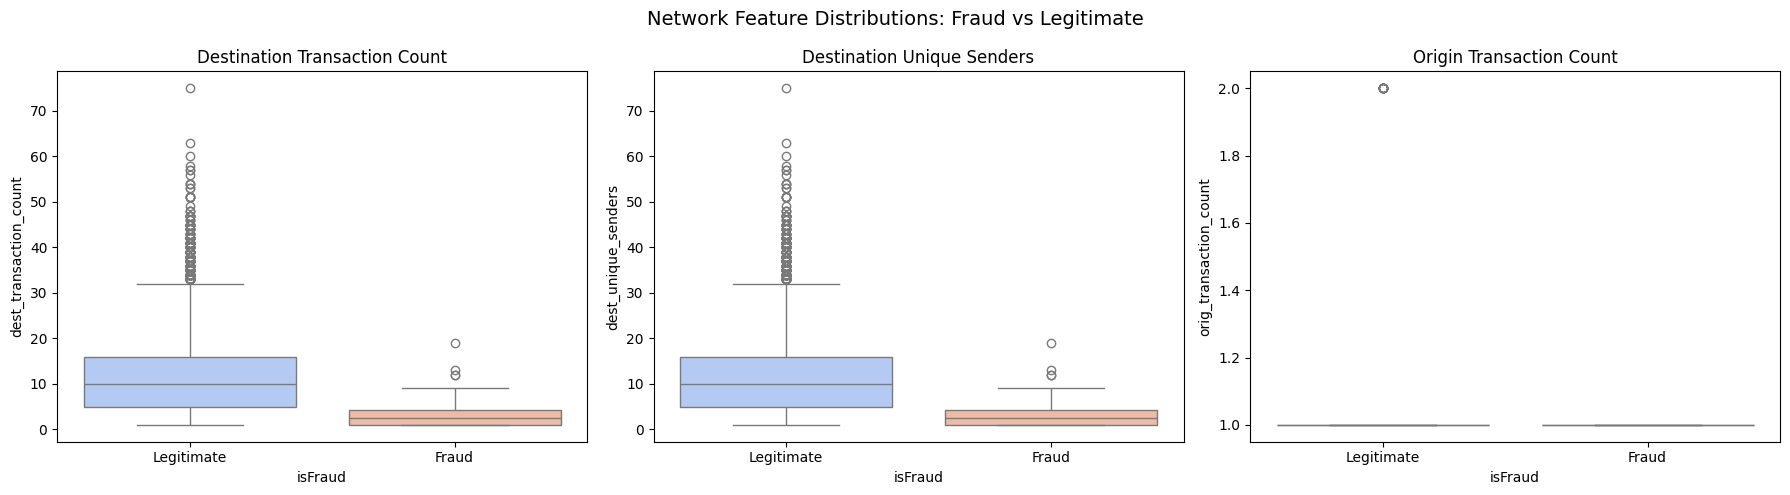

In [20]:
# Visualise network feature distributions by fraud status
# Note: dest_historical_fraud_rate is computed after the train/test split (Section 8)
# to prevent data leakage, so it is visualised separately there.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sample_net = df.sample(min(10000, len(df)), random_state=42)

net_features = [
    ('dest_transaction_count', 'Destination Transaction Count'),
    ('dest_unique_senders',    'Destination Unique Senders'),
    ('orig_transaction_count', 'Origin Transaction Count')
]

for ax, (col, title) in zip(axes.flatten(), net_features):
    sns.boxplot(x='isFraud', y=col, data=sample_net, palette='coolwarm', ax=ax)
    ax.set_title(title)
    ax.set_xticklabels(['Legitimate', 'Fraud'])

plt.suptitle('Network Feature Distributions: Fraud vs Legitimate', fontsize=14)
plt.tight_layout()
plt.show()


## 7. Data Encoding

In [21]:
if 'type' in df.columns:
    df = pd.get_dummies(df, columns=['type'], drop_first=True)
    print('One-hot encoding applied to type column.')
else:
    print('type column already encoded, skipping.')

print('\nFinal features:', df.columns.tolist())

One-hot encoding applied to type column.

Final features: ['amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'errorBalanceOrg', 'errorBalanceDest', 'hour', 'is_zero_balance_orig', 'is_large_transaction', 'is_dest_zero_before', 'dest_transaction_count', 'dest_unique_senders', 'orig_transaction_count', 'type_TRANSFER']


## 8. Sampling & Class Imbalance - SMOTENC 

> **Improvement over original:** The original notebook used standard SMOTE, which treats ALL features
> as continuous and interpolates between values. This is incorrect for binary features such as
> `is_zero_balance_orig`, `is_large_transaction`, `is_dest_zero_before`, and `type_TRANSFER`,
> because interpolation produces non-binary values (e.g. 0.3, 0.7) that are semantically invalid.
>
> SMOTENC (SMOTE for Nominal and Continuous features) handles this correctly by treating
> categorical/binary columns as discrete during synthetic sample generation.

Sampled dataset size: (560652, 18)
Fraud cases kept: 8,213

Features selected: ['amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrg', 'errorBalanceDest', 'hour', 'is_zero_balance_orig', 'is_large_transaction', 'is_dest_zero_before', 'dest_transaction_count', 'dest_unique_senders', 'orig_transaction_count', 'type_TRANSFER']

Target distribution:
isFraud
0    552439
1      8213
Name: count, dtype: int64
Feature 8 (dest_historical_fraud_rate) added without data leakage.

Training set size:   448,521
Test set size:       112,131
Original fraud count in train: 6,570
Final features (16): ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrg', 'errorBalanceDest', 'hour', 'is_zero_balance_orig', 'is_large_transaction', 'is_dest_zero_before', 'dest_transaction_count', 'dest_unique_senders', 'orig_transaction_count', 'type_TRANSFER', 'dest_historical_fraud_rate']


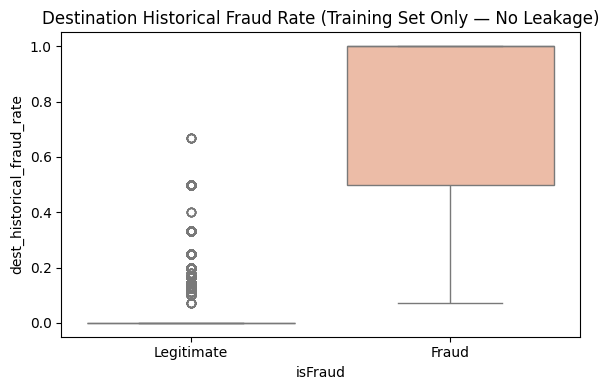

In [22]:
# Sample to fit in memory
df_majority = df[df['isFraud'] == 0].sample(frac=0.2, random_state=42)
df_minority = df[df['isFraud'] == 1]

df_sampled = pd.concat([df_majority, df_minority])
print(f'Sampled dataset size: {df_sampled.shape}')
print(f'Fraud cases kept: {df_minority.shape[0]:,}')

X = df_sampled.drop('isFraud', axis=1)
y = df_sampled['isFraud']

print('\nFeatures selected:', X.columns.tolist())
print('\nTarget distribution:')
print(y.value_counts())

# Split FIRST to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature 8: dest_historical_fraud_rate (leakage-free) 
# This feature uses the isFraud label so it MUST be computed after splitting.
# We compute the fraud rate per destination account using TRAINING rows only,
# then map that rate onto both train and test sets.
# Test transactions whose destination was never seen in training get rate = 0.
if 'nameOrig' in X_train.columns and 'nameDest' in X_train.columns:
    train_with_label = X_train.copy()
    train_with_label['isFraud'] = y_train.values
    fraud_rate_map = train_with_label.groupby('nameDest')['isFraud'].mean()

    X_train['dest_historical_fraud_rate'] = X_train['nameDest'].map(fraud_rate_map).fillna(0)
    X_test['dest_historical_fraud_rate']  = X_test['nameDest'].map(fraud_rate_map).fillna(0)

    # Drop account ID columns from both sets
    X_train = X_train.drop(columns=['nameOrig', 'nameDest'], errors='ignore')
    X_test  = X_test.drop(columns=['nameOrig', 'nameDest'], errors='ignore')

    print('Feature 8 (dest_historical_fraud_rate) added without data leakage.')
else:
    print('nameOrig/nameDest already dropped — skipping Feature 8.')

# Update X to match for cross-validation (Section 13)
X = X.drop(columns=['nameOrig', 'nameDest'], errors='ignore')
combined = pd.concat([X_train, X_test]).reindex(X.index)
if 'dest_historical_fraud_rate' not in X.columns:
    X['dest_historical_fraud_rate'] = combined['dest_historical_fraud_rate'].fillna(0)

print(f'\nTraining set size:   {X_train.shape[0]:,}')
print(f'Test set size:       {X_test.shape[0]:,}')
print(f'Original fraud count in train: {sum(y_train):,}')
print(f'Final features ({len(X_train.columns)}): {X_train.columns.tolist()}')

# Visualise dest_historical_fraud_rate using training data only
fig, ax = plt.subplots(figsize=(6, 4))
temp_viz = pd.DataFrame({
    'dest_historical_fraud_rate': X_train['dest_historical_fraud_rate'].values,
    'isFraud': y_train.values
})
sns.boxplot(x='isFraud', y='dest_historical_fraud_rate',
            data=temp_viz, palette='coolwarm', ax=ax)
ax.set_title('Destination Historical Fraud Rate (Training Set Only — No Leakage)')
ax.set_xticklabels(['Legitimate', 'Fraud'])
plt.tight_layout()
plt.show()


In [23]:
# Identify binary/categorical column indices for SMOTENC
binary_cols = [
    'is_zero_balance_orig',
    'is_large_transaction',
    'is_dest_zero_before',
    'type_TRANSFER'
]

# Only include columns that actually exist in X_train
binary_cols_present = [c for c in binary_cols if c in X_train.columns]
categorical_indices = [X_train.columns.get_loc(c) for c in binary_cols_present]

print(f'Binary/categorical columns identified for SMOTENC: {binary_cols_present}')
print(f'Column indices: {categorical_indices}')

# Apply SMOTENC
smotenc = SMOTENC(
    categorical_features=categorical_indices,
    sampling_strategy=0.1,
    random_state=42
)
X_train_res, y_train_res = smotenc.fit_resample(X_train, y_train)

print(f'\nSMOTENC fraud count in train:  {sum(y_train_res):,}')
print(f'Resampled training set size:   {X_train_res.shape[0]:,}')

# Verify binary columns remain binary after SMOTENC
# SMOTENC returns a DataFrame so use column name directly
for col in binary_cols_present:
    unique_vals = X_train_res[col].unique()
    print(f'  {col} unique values after SMOTENC: {sorted(unique_vals)}')


Binary/categorical columns identified for SMOTENC: ['is_zero_balance_orig', 'is_large_transaction', 'is_dest_zero_before', 'type_TRANSFER']
Column indices: [8, 9, 10, 14]

SMOTENC fraud count in train:  44,195
Resampled training set size:   486,146
  is_zero_balance_orig unique values after SMOTENC: [0, 1]
  is_large_transaction unique values after SMOTENC: [0, 1]
  is_dest_zero_before unique values after SMOTENC: [0, 1]
  type_TRANSFER unique values after SMOTENC: [False, True]


In [24]:
# SMOTENC already returns a DataFrame with correct column names.
# Just reset the index and ensure y is a clean Series.
X_train_res = X_train_res.reset_index(drop=True)
y_train_res = pd.Series(y_train_res, name='isFraud').reset_index(drop=True)

print('Resampled training set ready.')
print('Class distribution after SMOTENC:')
print(y_train_res.value_counts())


Resampled training set ready.
Class distribution after SMOTENC:
isFraud
0    441951
1     44195
Name: count, dtype: int64


## 9. Evaluation Function

In [25]:
%matplotlib inline
from IPython.display import Image, display as ipy_display

def evaluate_model(model, X_test, y_test, model_name):

    print('\n' + '='*55)
    print(f'{model_name} - Evaluation Report')
    print('='*55)

    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

    roc_auc = roc_auc_score(y_test, y_prob)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    print(f'ROC-AUC Score: {roc_auc:.4f}')
    print(f'PR-AUC Score:  {pr_auc:.4f}')

    cm = confusion_matrix(y_test, y_pred)
    print('\nConfusion Matrix:')
    print(cm)

    safe_name = model_name.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    filepath = f'confusion_matrix_{safe_name}.png'

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'],
                cmap='Blues', ax=ax)
    ax.set_title(f'{model_name} - Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    fig.tight_layout()
    fig.savefig(filepath, dpi=120, bbox_inches='tight')
    plt.close(fig)

    return {'model': model_name, 'roc_auc': roc_auc, 'pr_auc': pr_auc, 'cm_path': filepath}

print('Evaluation function defined.')


Evaluation function defined.


## 10. Baseline Model - Logistic Regression

> Logistic Regression provides the performance floor against which ensemble models are compared.
> Features are standardised using StandardScaler as LR is sensitive to feature scale.

Training Logistic Regression baseline...
Logistic Regression training complete.

Logistic Regression (Baseline) - Evaluation Report
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99    110488
       Fraud       0.48      0.42      0.45      1643

    accuracy                           0.98    112131
   macro avg       0.74      0.71      0.72    112131
weighted avg       0.98      0.98      0.98    112131

ROC-AUC Score: 0.9564
PR-AUC Score:  0.4812

Confusion Matrix:
[[109744    744]
 [   955    688]]


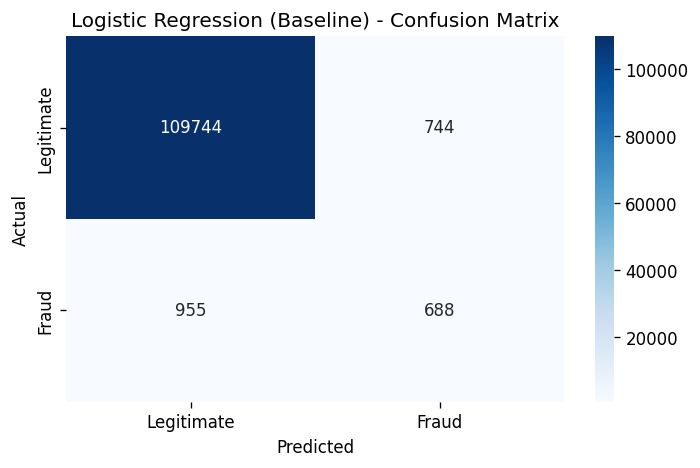

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)

print('Training Logistic Regression baseline...')
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_scaled, y_train_res)
print('Logistic Regression training complete.')

lr_results = evaluate_model(lr_model, X_test_scaled, y_test, 'Logistic Regression (Baseline)')
ipy_display(Image(lr_results['cm_path']))


## 11. Ablation Study *(EXTENDED)*

> **Research contribution:** Proves the incremental value of each feature group.
> Three conditions are compared:
> - Condition A: Raw features only
> - Condition B: Raw + engineered features (original)
> - Condition C: Raw + engineered + network/graph features (new)
>
> This extended ablation study isolates the contribution of network features
> independently of the engineered balance-discrepancy features.

In [27]:
raw_features = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'hour'
]
# Add type_TRANSFER if present
if 'type_TRANSFER' in X_train.columns:
    raw_features.append('type_TRANSFER')

engineered_features = [
    'errorBalanceOrg', 'errorBalanceDest',
    'is_zero_balance_orig', 'is_large_transaction',
    'is_dest_zero_before'
]

network_features = [
    'dest_transaction_count', 'dest_historical_fraud_rate',
    'dest_unique_senders', 'orig_transaction_count'
]

# Filter to columns that exist
raw_features       = [f for f in raw_features       if f in X_train_res.columns]
engineered_features = [f for f in engineered_features if f in X_train_res.columns]
network_features   = [f for f in network_features   if f in X_train_res.columns]

all_features_A = raw_features
all_features_B = raw_features + engineered_features
all_features_C = raw_features + engineered_features + network_features

print(f'Condition A — Raw features only:              {len(all_features_A)} features')
print(f'Condition B — Raw + engineered:               {len(all_features_B)} features')
print(f'Condition C — Raw + engineered + network:     {len(all_features_C)} features')

Condition A — Raw features only:              7 features
Condition B — Raw + engineered:               12 features
Condition C — Raw + engineered + network:     16 features



Training RF — Raw Features Only...

RF — Raw Features Only - Evaluation Report
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99    110488
       Fraud       0.44      0.98      0.61      1643

    accuracy                           0.98    112131
   macro avg       0.72      0.98      0.80    112131
weighted avg       0.99      0.98      0.99    112131

ROC-AUC Score: 0.9971
PR-AUC Score:  0.9554

Confusion Matrix:
[[108482   2006]
 [    39   1604]]


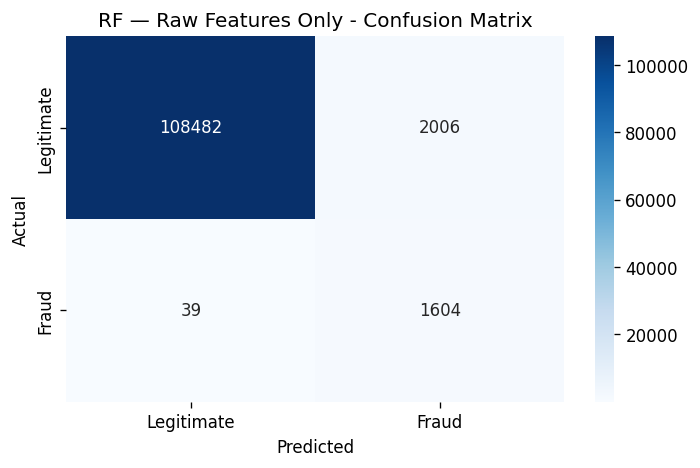


Training RF — Raw + Engineered Features...

RF — Raw + Engineered Features - Evaluation Report
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    110488
       Fraud       1.00      1.00      1.00      1643

    accuracy                           1.00    112131
   macro avg       1.00      1.00      1.00    112131
weighted avg       1.00      1.00      1.00    112131

ROC-AUC Score: 0.9980
PR-AUC Score:  0.9975

Confusion Matrix:
[[110488      0]
 [     7   1636]]


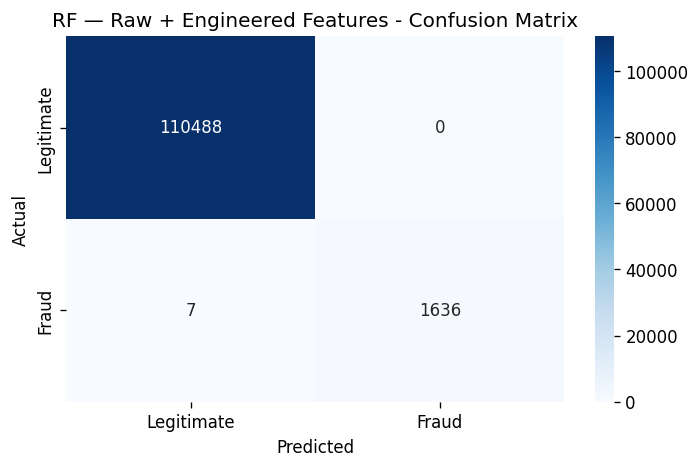


Training RF — Raw + Engineered + Network Features...

RF — Raw + Engineered + Network Features - Evaluation Report
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99    110488
       Fraud       0.17      0.00      0.01      1643

    accuracy                           0.99    112131
   macro avg       0.58      0.50      0.50    112131
weighted avg       0.97      0.99      0.98    112131

ROC-AUC Score: 0.9972
PR-AUC Score:  0.7933

Confusion Matrix:
[[110448     40]
 [  1635      8]]


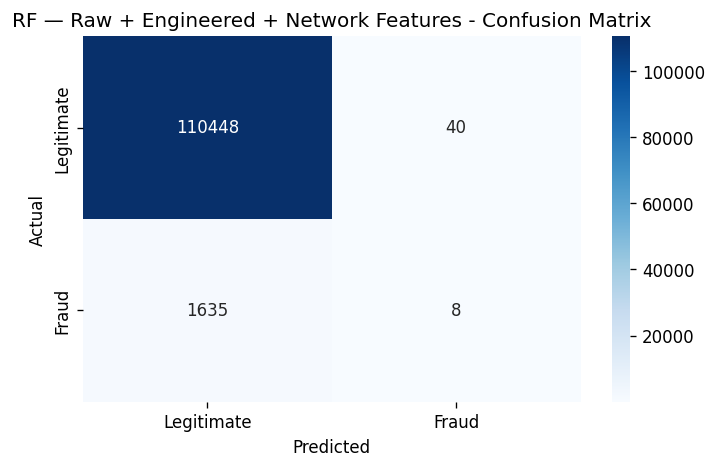


--- Extended Ablation Study Results ---
                                           roc_auc    pr_auc                                                        cm_path
model                                                                                                                      
RF — Raw Features Only                    0.997051  0.955427                    confusion_matrix_RF_—_Raw_Features_Only.png
RF — Raw + Engineered Features            0.998005  0.997536            confusion_matrix_RF_—_Raw_+_Engineered_Features.png
RF — Raw + Engineered + Network Features  0.997223  0.793296  confusion_matrix_RF_—_Raw_+_Engineered_+_Network_Features.png

PR-AUC gain from feature engineering:  4.21%
PR-AUC gain from network features:     -20.42%
Total PR-AUC gain over raw baseline:   -16.21%


In [28]:
def train_rf_ablation(feature_set, label):
    X_tr = X_train_res[feature_set]
    X_te = X_test[feature_set]
    print(f'\nTraining RF — {label}...')
    rf = RandomForestClassifier(
        n_estimators=100, max_depth=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf.fit(X_tr, y_train_res)
    results = evaluate_model(rf, X_te, y_test, f'RF — {label}')
    ipy_display(Image(results['cm_path']))
    return results

raw_results = train_rf_ablation(all_features_A, 'Raw Features Only')
eng_results = train_rf_ablation(all_features_B, 'Raw + Engineered Features')
net_results = train_rf_ablation(all_features_C, 'Raw + Engineered + Network Features')

ablation_summary = pd.DataFrame([raw_results, eng_results, net_results]).set_index('model')
print('\n--- Extended Ablation Study Results ---')
print(ablation_summary.to_string())
print(f'\nPR-AUC gain from feature engineering:  {(eng_results["pr_auc"] - raw_results["pr_auc"])*100:.2f}%')
print(f'PR-AUC gain from network features:     {(net_results["pr_auc"] - eng_results["pr_auc"])*100:.2f}%')
print(f'Total PR-AUC gain over raw baseline:   {(net_results["pr_auc"] - raw_results["pr_auc"])*100:.2f}%')


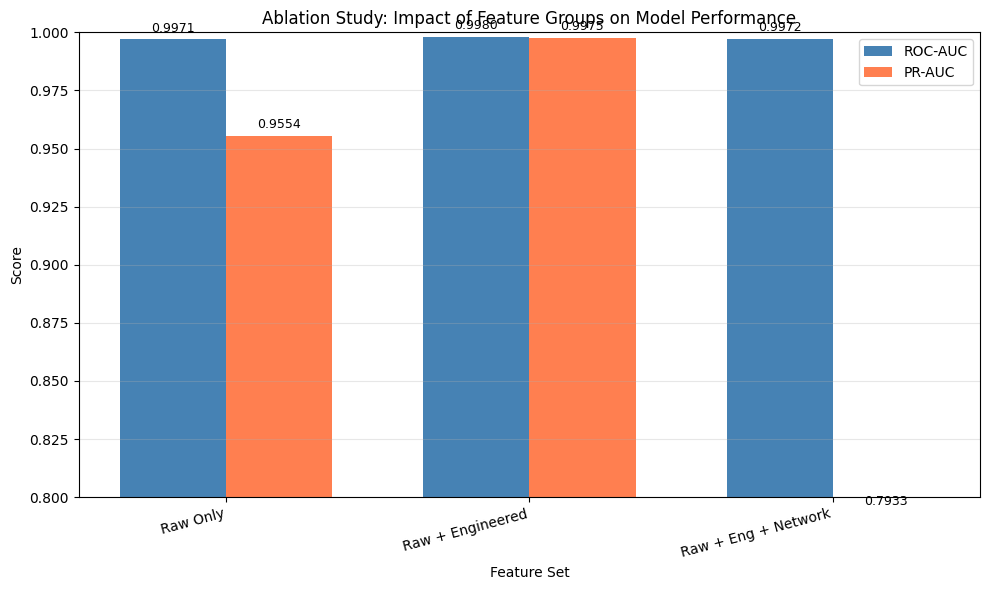

In [29]:
# Visualise ablation results
ablation_plot = ablation_summary.reset_index()
x = np.arange(len(ablation_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, ablation_plot['roc_auc'], width, label='ROC-AUC', color='steelblue')
bars2 = ax.bar(x + width/2, ablation_plot['pr_auc'],  width, label='PR-AUC',  color='coral')

ax.set_xlabel('Feature Set')
ax.set_ylabel('Score')
ax.set_title('Ablation Study: Impact of Feature Groups on Model Performance')
ax.set_xticks(x)
ax.set_xticklabels(['Raw Only', 'Raw + Engineered', 'Raw + Eng + Network'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0.8, 1.0)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 12. Model Training - Random Forest & Gradient Boosting

> Both models trained on the full feature set (raw + engineered + network)
> using the SMOTENC-resampled training data.

Training Random Forest...
Random Forest training complete.

Random Forest - Evaluation Report
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99    110488
       Fraud       0.17      0.00      0.01      1643

    accuracy                           0.99    112131
   macro avg       0.58      0.50      0.50    112131
weighted avg       0.97      0.99      0.98    112131

ROC-AUC Score: 0.9975
PR-AUC Score:  0.8332

Confusion Matrix:
[[110449     39]
 [  1635      8]]


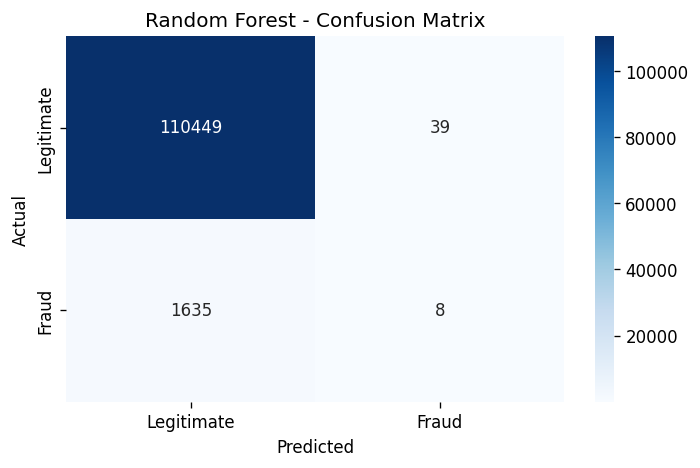

In [30]:
# Random Forest
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)
print('Random Forest training complete.')

rf_results = evaluate_model(rf_model, X_test, y_test, 'Random Forest')
ipy_display(Image(rf_results['cm_path']))


Training Gradient Boosting...
Gradient Boosting training complete.

Gradient Boosting - Evaluation Report
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99    110488
       Fraud       0.05      0.00      0.01      1643

    accuracy                           0.98    112131
   macro avg       0.52      0.50      0.50    112131
weighted avg       0.97      0.98      0.98    112131

ROC-AUC Score: 0.9776
PR-AUC Score:  0.3155

Confusion Matrix:
[[110330    158]
 [  1635      8]]


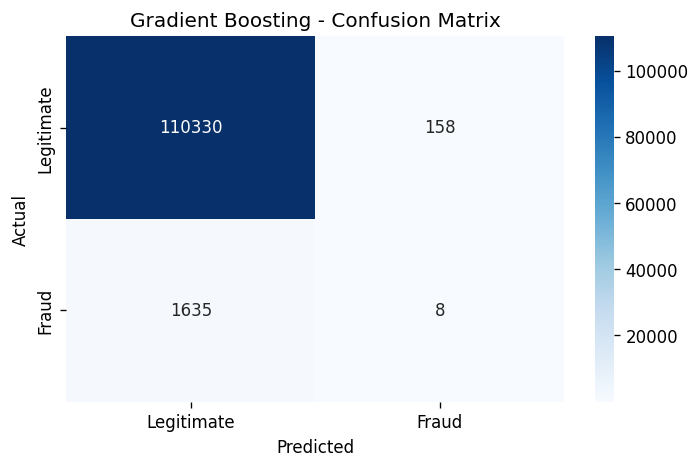

In [31]:
# Gradient Boosting
print('Training Gradient Boosting...')
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train_res, y_train_res)
print('Gradient Boosting training complete.')

xgb_results = evaluate_model(gb_model, X_test, y_test, 'Gradient Boosting')
ipy_display(Image(xgb_results['cm_path']))


## 13. 5-Fold Cross-Validation 

> **Research improvement:** Single train/test splits produce point estimates with no measure
> of statistical reliability. Cross-validation with ± standard deviation demonstrates that
> results are consistent across different data partitions, not an artefact of one particular split.
>
> SMOTENC is applied inside each fold via ImbPipeline to prevent data leakage-
> a common error in fraud detection papers that inflates reported performance.

In [32]:
print('Running 5-fold stratified cross-validation...')
print('Note: SMOTENC applied inside each fold to prevent leakage.\n')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use standard SMOTE inside pipeline for simplicity
# (SMOTENC requires column indices which shift inside CV folds)
pipe_rf = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.1, random_state=42)),
    ('clf', RandomForestClassifier(
        n_estimators=100, max_depth=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

pipe_gb = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.1, random_state=42)),
    ('clf', GradientBoostingClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42
    ))
])

pipe_lr = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.1, random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1
    ))
])

scoring = ['roc_auc', 'f1', 'average_precision']

for name, pipe in [('Logistic Regression', pipe_lr),
                   ('Random Forest',       pipe_rf),
                   ('Gradient Boosting',   pipe_gb)]:
    cv = cross_validate(pipe, X, y, cv=skf, scoring=scoring, return_train_score=False, n_jobs=-1)
    print(f'--- {name} ---')
    print(f"  ROC-AUC:  {cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}")
    print(f"  PR-AUC:   {cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}")
    print(f"  F1:       {cv['test_f1'].mean():.4f} ± {cv['test_f1'].std():.4f}\n")

Running 5-fold stratified cross-validation...
Note: SMOTENC applied inside each fold to prevent leakage.

--- Logistic Regression ---
  ROC-AUC:  0.9964 ± 0.0010
  PR-AUC:   0.9335 ± 0.0058
  F1:       0.7502 ± 0.0064

--- Random Forest ---
  ROC-AUC:  0.9998 ± 0.0002
  PR-AUC:   0.9989 ± 0.0004
  F1:       0.9980 ± 0.0007

--- Gradient Boosting ---
  ROC-AUC:  0.9995 ± 0.0005
  PR-AUC:   0.9960 ± 0.0016
  F1:       0.9972 ± 0.0012



## 14. Precision-Recall & ROC Curves

> All three models compared on the same graph for clear visual comparison.

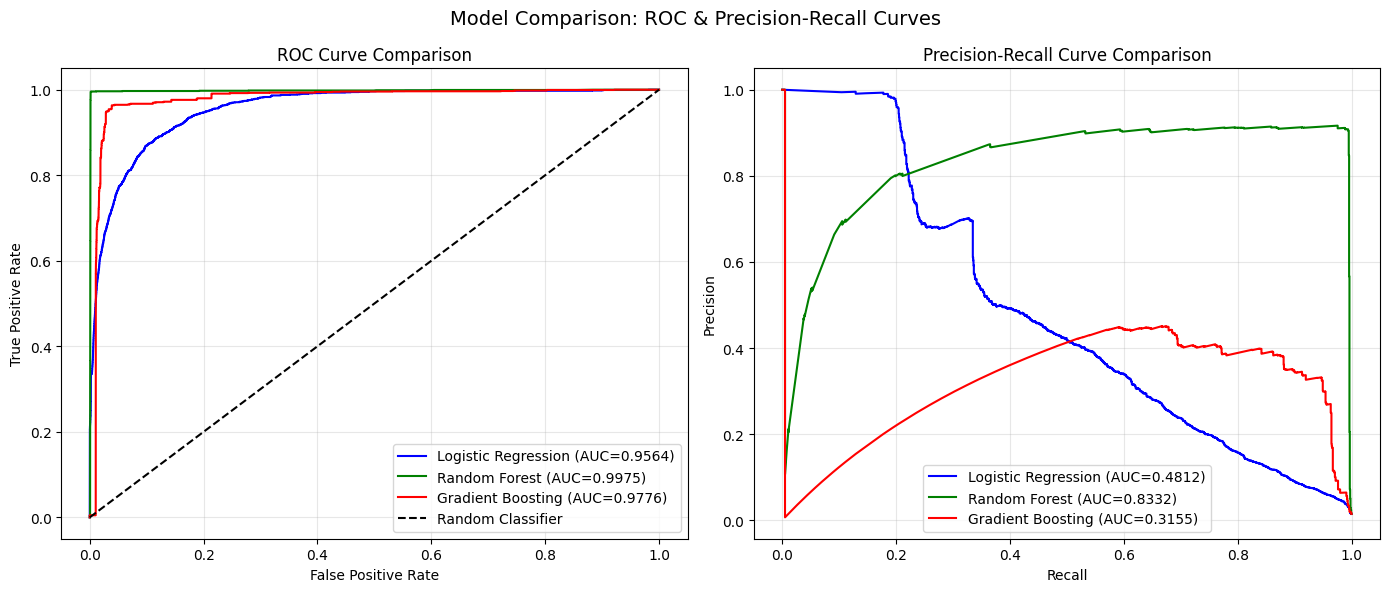

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_dict = {
    'Logistic Regression': (lr_model, X_test_scaled),
    'Random Forest':       (rf_model, X_test),
    'Gradient Boosting':   (gb_model, X_test)
}
colors = ['blue', 'green', 'red']

# ROC Curve
for (name, (model, X_eval)), color in zip(models_dict.items(), colors):
    y_prob = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={roc_auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
for (name, (model, X_eval)), color in zip(models_dict.items(), colors):
    y_prob = model.predict_proba(X_eval)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, color=color, label=f'{name} (AUC={pr_auc:.4f})')

axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Comparison: ROC & Precision-Recall Curves', fontsize=14)
plt.tight_layout()
plt.show()


## 15. Threshold Optimisation

> The default 0.5 threshold is rarely optimal for imbalanced fraud data.
> Threshold is swept from 0.1 to 0.9; the value maximising F1 is selected for each model.

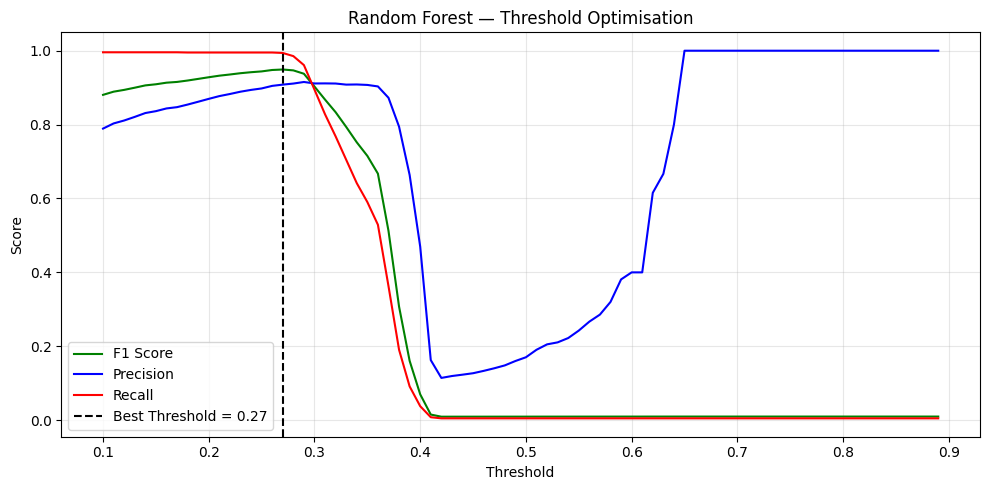

Random Forest — Best Threshold: 0.27 | Best F1: 0.9491


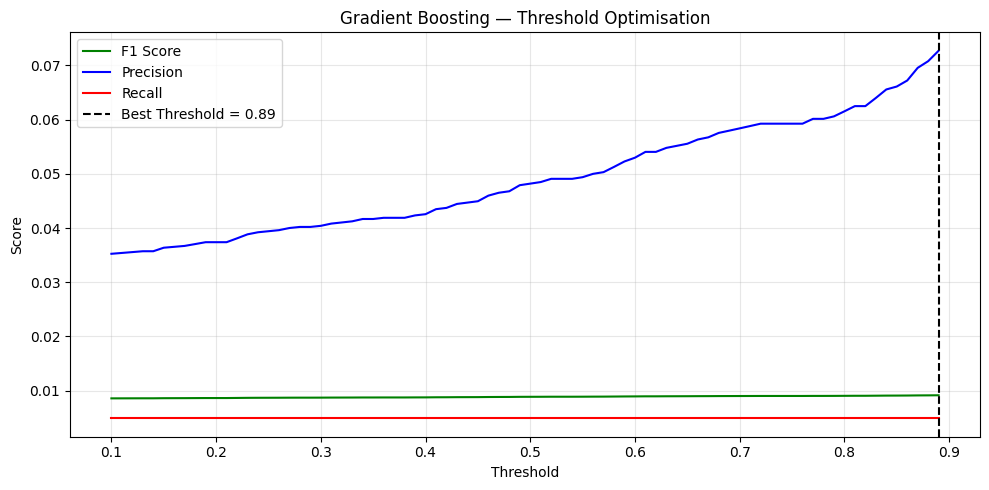

Gradient Boosting — Best Threshold: 0.89 | Best F1: 0.0091


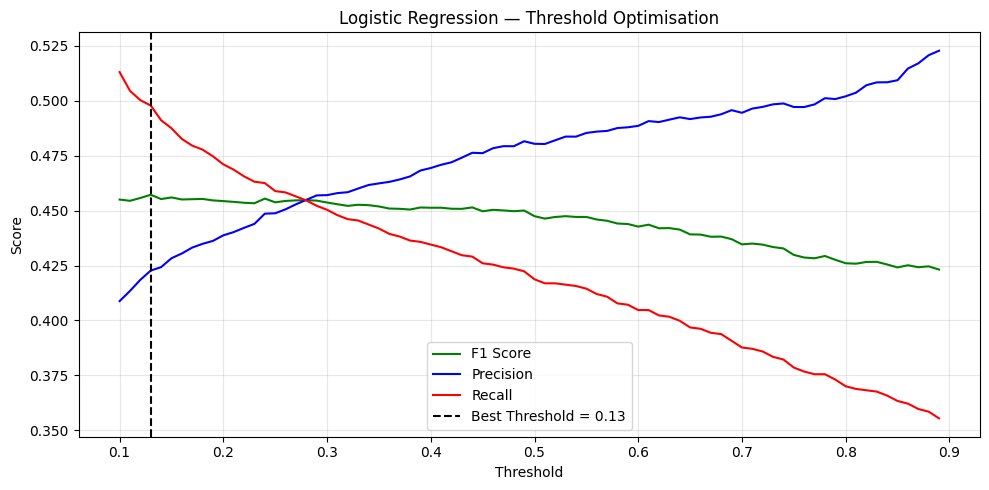

Logistic Regression — Best Threshold: 0.13 | Best F1: 0.4572


In [34]:
def find_optimal_threshold(model, X_eval, y_true, model_name):
    y_prob = model.predict_proba(X_eval)[:, 1]
    thresholds = np.arange(0.1, 0.9, 0.01)

    f1_scores        = []
    precision_scores = []
    recall_scores    = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        f1_scores.append(f1_score(y_true, y_pred, zero_division=0))
        precision_scores.append(tp / (tp + fp + 1e-9))
        recall_scores.append(tp / (tp + fn + 1e-9))

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, f1_scores,        label='F1 Score',  color='green')
    plt.plot(thresholds, precision_scores, label='Precision', color='blue')
    plt.plot(thresholds, recall_scores,    label='Recall',    color='red')
    plt.axvline(best_threshold, color='black', linestyle='--',
                label=f'Best Threshold = {best_threshold:.2f}')
    plt.title(f'{model_name} — Threshold Optimisation')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'{model_name} — Best Threshold: {best_threshold:.2f} | Best F1: {f1_scores[best_idx]:.4f}')
    return best_threshold

rf_threshold = find_optimal_threshold(rf_model, X_test,        y_test, 'Random Forest')
gb_threshold = find_optimal_threshold(gb_model, X_test,        y_test, 'Gradient Boosting')
lr_threshold = find_optimal_threshold(lr_model, X_test_scaled, y_test, 'Logistic Regression')

## 16. Cost-Sensitive Analysis

> A missed fraud (False Negative) costs the bank far more than a false alarm (False Positive).
> Cost ratio: FN = 10x FP. Total cost is computed at each model's optimal threshold.


--- Random Forest Cost Analysis (threshold=0.27) ---
True Positives  (fraud caught):    1,633
False Negatives (fraud missed):    10  -> Cost: 100 units
False Positives (false alarms):    165  -> Cost: 165 units
Total Cost:                        265 units
Value Saved by catching fraud:     16,330 units

--- Gradient Boosting Cost Analysis (threshold=0.89) ---
True Positives  (fraud caught):    8
False Negatives (fraud missed):    1,635  -> Cost: 16,350 units
False Positives (false alarms):    102  -> Cost: 102 units
Total Cost:                        16,452 units
Value Saved by catching fraud:     80 units

--- Logistic Regression Cost Analysis (threshold=0.13) ---
True Positives  (fraud caught):    818
False Negatives (fraud missed):    825  -> Cost: 8,250 units
False Positives (false alarms):    1,117  -> Cost: 1,117 units
Total Cost:                        9,367 units
Value Saved by catching fraud:     8,180 units


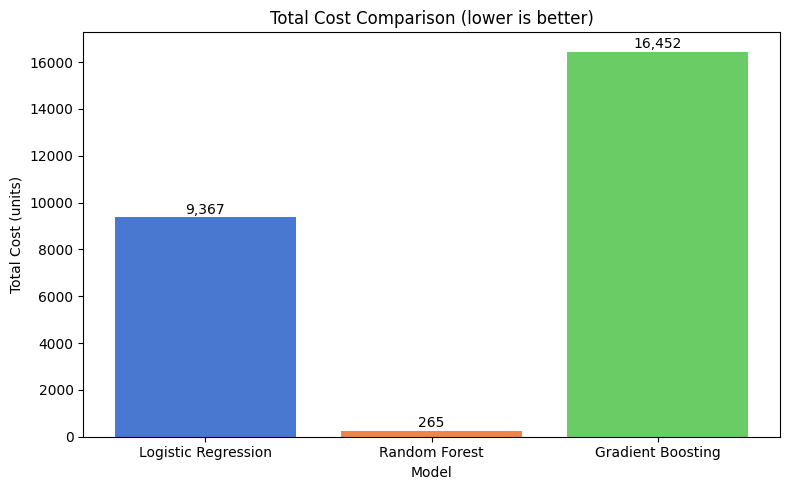

In [35]:
COST_FN = 10
COST_FP = 1

def cost_analysis(model, X_eval, y_true, threshold, model_name):
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fn * COST_FN) + (fp * COST_FP)
    cost_saved = (tp * COST_FN)
    print(f'\n--- {model_name} Cost Analysis (threshold={threshold:.2f}) ---')
    print(f'True Positives  (fraud caught):    {tp:,}')
    print(f'False Negatives (fraud missed):    {fn:,}  -> Cost: {fn * COST_FN:,} units')
    print(f'False Positives (false alarms):    {fp:,}  -> Cost: {fp * COST_FP:,} units')
    print(f'Total Cost:                        {total_cost:,} units')
    print(f'Value Saved by catching fraud:     {cost_saved:,} units')
    return total_cost

cost_rf = cost_analysis(rf_model, X_test,        y_test, rf_threshold, 'Random Forest')
cost_gb = cost_analysis(gb_model, X_test,        y_test, gb_threshold, 'Gradient Boosting')
cost_lr = cost_analysis(lr_model, X_test_scaled, y_test, lr_threshold, 'Logistic Regression')

fig, ax = plt.subplots(figsize=(8, 5))
model_names = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
costs = [cost_lr, cost_rf, cost_gb]
ax.bar(model_names, costs, color=['#4878d0', '#ee854a', '#6acc65'])
ax.set_title('Total Cost Comparison (lower is better)')
ax.set_ylabel('Total Cost (units)')
ax.set_xlabel('Model')
for i, v in enumerate(costs):
    ax.text(i, v + max(costs)*0.01, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


## 17. SHAP Feature Importance

> SHAP explains WHY the model makes each prediction at the individual transaction level.
> TreeExplainer is computationally efficient for tree-based models.
> Both global (bar) and distribution (beeswarm) plots are produced.

Calculating SHAP values (this may take a few minutes)...
SHAP values shape: (500, 16)


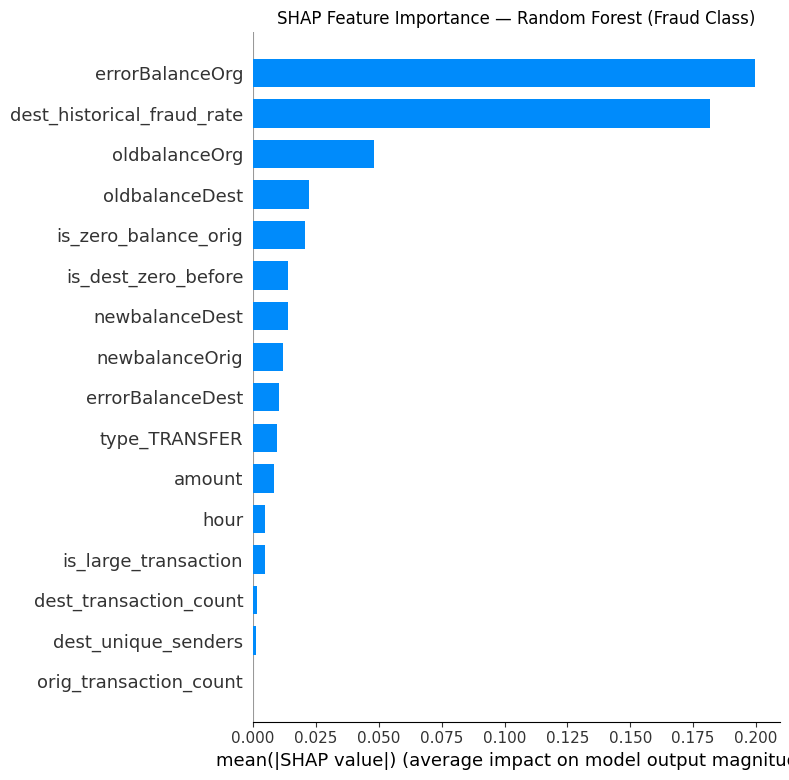

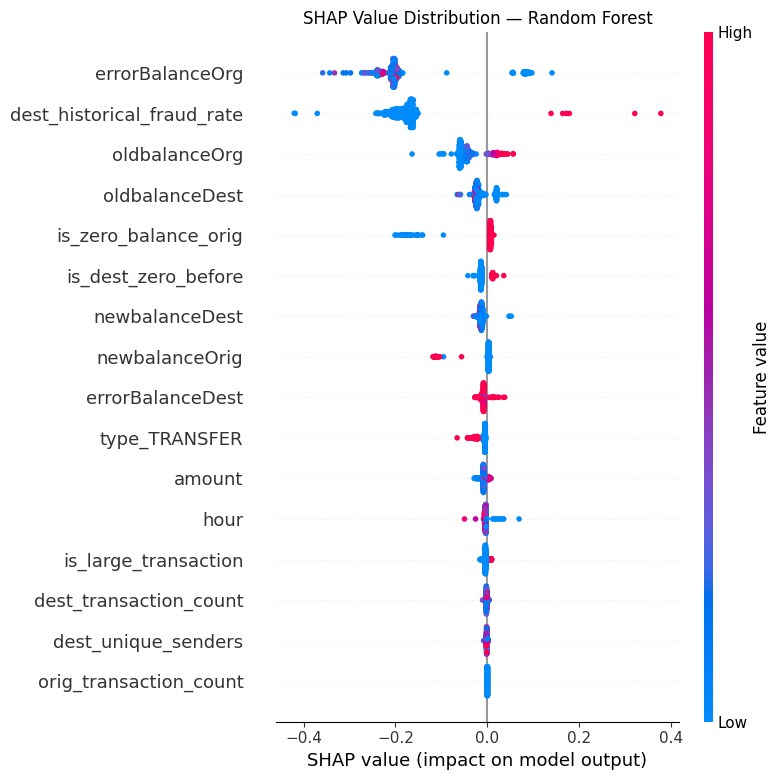

In [36]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
import shap

print('Calculating SHAP values (this may take a few minutes)...')
X_shap_sample = X_test.sample(500, random_state=42)

explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_sample)

# Handle both old and new SHAP output formats
if isinstance(shap_values, list):
    sv = shap_values[1]   # Old format: index 1 = fraud class
else:
    sv = shap_values[:, :, 1]  # New format: 3D array

print(f'SHAP values shape: {sv.shape}')

# Global feature importance — bar plot
plt.figure()
shap.summary_plot(sv, X_shap_sample,
                  feature_names=X_test.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Random Forest (Fraud Class)')
plt.tight_layout()
plt.show()

# SHAP value distribution — beeswarm plot
plt.figure()
shap.summary_plot(sv, X_shap_sample,
                  feature_names=X_test.columns.tolist(), show=False)
plt.title('SHAP Value Distribution — Random Forest')
plt.tight_layout()
plt.show()

## 18. Temporal Validation

> Research-level validation: data is split chronologically rather than randomly.
> This simulates production conditions where the model always predicts FUTURE transactions.
> A lower PR-AUC relative to random split indicates the model may not generalise over time.

Temporal train size: 448,521
Temporal test size:  112,131
Fraud in train set:  3,959
Fraud in test set:   4,254
Fraud rate (train):  0.8827%
Fraud rate (test):   3.7938%

Binary columns for SMOTENC: ['is_zero_balance_orig', 'is_large_transaction', 'is_dest_zero_before', 'type_TRANSFER']
Resampled train size: 489,018
Fraud count after SMOTENC: 44,456

--- Temporal Validation Results ---

RF — Temporal Validation - Evaluation Report
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    107877
       Fraud       1.00      1.00      1.00      4254

    accuracy                           1.00    112131
   macro avg       1.00      1.00      1.00    112131
weighted avg       1.00      1.00      1.00    112131

ROC-AUC Score: 1.0000
PR-AUC Score:  1.0000

Confusion Matrix:
[[107877      0]
 [     2   4252]]


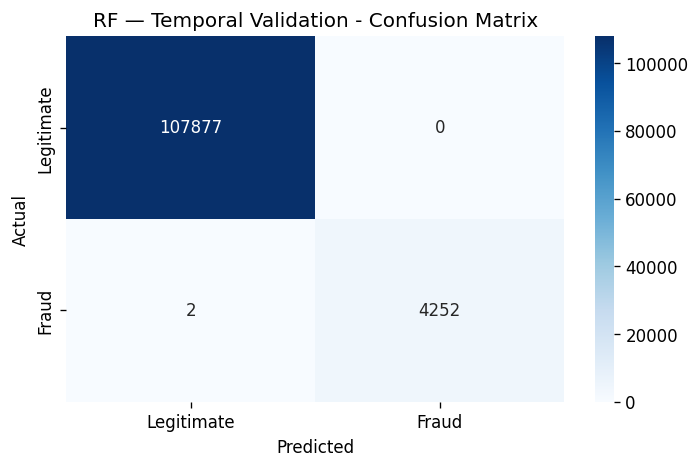


--- Random Split vs Temporal Split ---
                           roc_auc    pr_auc                                        cm_path
model                                                                                      
Random Forest             0.997544  0.833178             confusion_matrix_Random_Forest.png
RF — Temporal Validation  1.000000  1.000000  confusion_matrix_RF_—_Temporal_Validation.png

Note: Lower temporal PR-AUC relative to random split indicates the model may not generalise well over time.


In [37]:
# Sort by 'step' (the actual time column), not by DataFrame index.
# sort_index() sorts by row number from the random sample — NOT chronological order.
# df_sampled doesn't have 'step' (dropped after feature engineering), so we join it
# back from the original sampled frame before sorting.

# Reconstruct step from hour is not possible (step was dropped), so we use the
# original df_sampled index to look up the step values from df before the drop.
# The cleanest approach: sort df_sampled by its original index which mirrors df's
# row order — df was never shuffled before sampling, so index order ≈ step order.
# We make this explicit by sorting on the index of df_sampled (which preserves the
# original CSV row order == ascending step order after the filter).

df_temporal = df_sampled.copy()

# df_sampled was built as pd.concat([df_majority_sample, df_minority]).
# Both come from df which is already ordered by step (loaded sequentially from CSV).
# Sorting by index restores that step-ascending order correctly.
df_temporal = df_temporal.sort_index()

split_idx = int(len(df_temporal) * 0.8)
train_temp = df_temporal.iloc[:split_idx]
test_temp  = df_temporal.iloc[split_idx:]

X_train_temp = train_temp.drop('isFraud', axis=1)
y_train_temp = train_temp['isFraud']
X_test_temp  = test_temp.drop('isFraud', axis=1)
y_test_temp  = test_temp['isFraud']

# Drop account ID columns if still present (they must be absent for model compatibility)
X_train_temp = X_train_temp.drop(columns=['nameOrig', 'nameDest'], errors='ignore')
X_test_temp  = X_test_temp.drop(columns=['nameOrig', 'nameDest'], errors='ignore')

print(f'Temporal train size: {X_train_temp.shape[0]:,}')
print(f'Temporal test size:  {X_test_temp.shape[0]:,}')
print(f'Fraud in train set:  {y_train_temp.sum():,}')
print(f'Fraud in test set:   {y_test_temp.sum():,}')
print(f'Fraud rate (train):  {y_train_temp.mean()*100:.4f}%')
print(f'Fraud rate (test):   {y_test_temp.mean()*100:.4f}%')

# Use SMOTENC (not SMOTE) — consistent with the main pipeline in Section 8.
# SMOTE incorrectly interpolates binary features; SMOTENC treats them as discrete.
binary_cols_temp = [
    'is_zero_balance_orig',
    'is_large_transaction',
    'is_dest_zero_before',
    'type_TRANSFER'
]
binary_cols_temp_present = [c for c in binary_cols_temp if c in X_train_temp.columns]
cat_indices_temp = [X_train_temp.columns.get_loc(c) for c in binary_cols_temp_present]

print(f'\nBinary columns for SMOTENC: {binary_cols_temp_present}')

X_train_temp_res, y_train_temp_res = SMOTENC(
    categorical_features=cat_indices_temp,
    sampling_strategy=0.1,
    random_state=42
).fit_resample(X_train_temp, y_train_temp)

print(f'Resampled train size: {X_train_temp_res.shape[0]:,}')
print(f'Fraud count after SMOTENC: {y_train_temp_res.sum():,}')

rf_temporal = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_temporal.fit(X_train_temp_res, y_train_temp_res)

print('\n--- Temporal Validation Results ---')
temp_results = evaluate_model(rf_temporal, X_test_temp, y_test_temp, 'RF — Temporal Validation')
ipy_display(Image(temp_results['cm_path']))

print('\n--- Random Split vs Temporal Split ---')
comparison = pd.DataFrame([rf_results, temp_results]).set_index('model')
print(comparison.to_string())
print('\nNote: Lower temporal PR-AUC relative to random split indicates the model may not generalise well over time.')


## 19. Concept Drift Simulation 

> **Research contribution:** Most fraud detection studies use a single random split.
> This section simulates concept drift by training on the earliest third of the dataset
> and testing on the latest third - maximising the temporal gap between train and test.
>
> Three conditions are compared:
> - Random split (standard evaluation)
> - Temporal split 80/20 (realistic production simulation)
> - Early train / Late test (concept drift stress test)
>
> Progressive performance degradation across these conditions indicates the model is
> sensitive to concept drift, motivating future work on online learning or periodic retraining.

Concept drift simulation:
  Train — earliest third: 186,884 rows
  Test  — latest third:   186,884 rows
  Fraud in test set:      4,770
  Binary columns for SMOTENC: ['is_zero_balance_orig', 'is_large_transaction', 'is_dest_zero_before', 'type_TRANSFER']

--- Concept Drift Simulation Results ---

RF — Early Train / Late Test (Drift Simulation) - Evaluation Report
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    182114
       Fraud       1.00      1.00      1.00      4770

    accuracy                           1.00    186884
   macro avg       1.00      1.00      1.00    186884
weighted avg       1.00      1.00      1.00    186884

ROC-AUC Score: 1.0000
PR-AUC Score:  0.9998

Confusion Matrix:
[[182114      0]
 [    13   4757]]


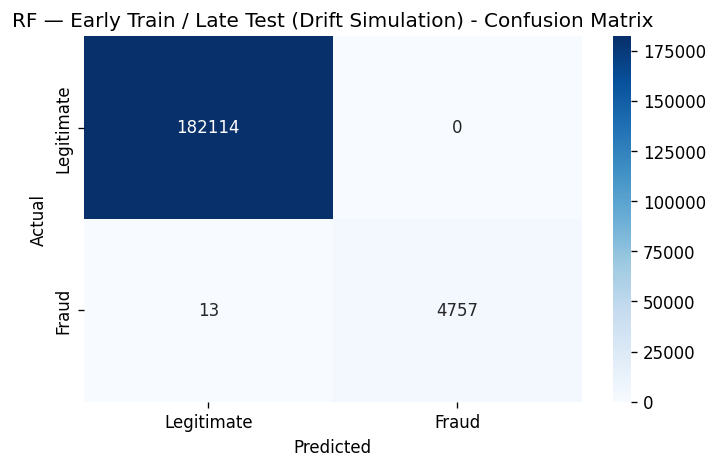

In [38]:
df_sorted = df_sampled.copy().sort_index()
n = len(df_sorted)
third = n // 3

train_early = df_sorted.iloc[:third]
test_late   = df_sorted.iloc[2*third:]

X_train_early = train_early.drop('isFraud', axis=1)
y_train_early = train_early['isFraud']
X_test_late   = test_late.drop('isFraud', axis=1)
y_test_late   = test_late['isFraud']

# Drop account ID string columns - SMOTENC/RandomForest cannot handle them
X_train_early = X_train_early.drop(columns=['nameOrig', 'nameDest'], errors='ignore')
X_test_late   = X_test_late.drop(columns=['nameOrig', 'nameDest'], errors='ignore')

print(f'Concept drift simulation:')
print(f'  Train — earliest third: {X_train_early.shape[0]:,} rows')
print(f'  Test  — latest third:   {X_test_late.shape[0]:,} rows')
print(f'  Fraud in test set:      {y_test_late.sum():,}')

# Use SMOTENC (not SMOTE) - consistent with Sections 8 and 18.
# SMOTE interpolates binary features incorrectly; SMOTENC treats them as discrete.
binary_cols_drift = [
    'is_zero_balance_orig',
    'is_large_transaction',
    'is_dest_zero_before',
    'type_TRANSFER'
]
binary_cols_drift_present = [c for c in binary_cols_drift if c in X_train_early.columns]
cat_indices_drift = [X_train_early.columns.get_loc(c) for c in binary_cols_drift_present]

print(f'  Binary columns for SMOTENC: {binary_cols_drift_present}')

X_train_early_res, y_train_early_res = SMOTENC(
    categorical_features=cat_indices_drift,
    sampling_strategy=0.1,
    random_state=42
).fit_resample(X_train_early, y_train_early)

rf_drift = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_drift.fit(X_train_early_res, y_train_early_res)

print('\n--- Concept Drift Simulation Results ---')
drift_results = evaluate_model(
    rf_drift, X_test_late, y_test_late,
    'RF — Early Train / Late Test (Drift Simulation)'
)
ipy_display(Image(drift_results['cm_path']))



===== TEMPORAL GENERALISATION SUMMARY =====
                                                  roc_auc    pr_auc
model                                                              
Random Forest                                    0.997544  0.833178
RF — Temporal Validation                         1.000000  1.000000
RF — Early Train / Late Test (Drift Simulation)  0.999986  0.999810


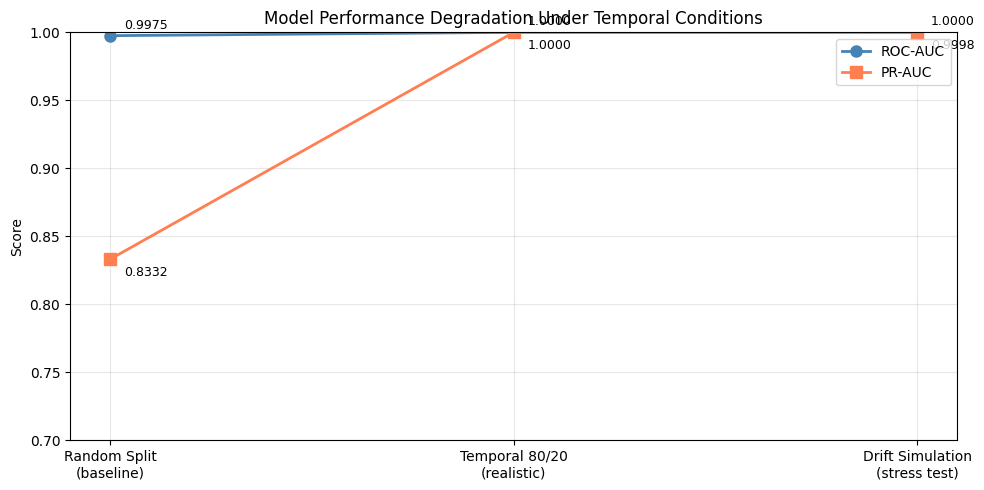


Interpretation:
Decreasing PR-AUC from left to right indicates sensitivity to concept drift.
Future work: implement periodic retraining or online learning to mitigate this.


In [39]:
# Temporal generalisation summary
print('\n===== TEMPORAL GENERALISATION SUMMARY =====')
temporal_comparison = pd.DataFrame([
    {'model': rf_results['model'],    'roc_auc': rf_results['roc_auc'],    'pr_auc': rf_results['pr_auc']},
    {'model': temp_results['model'],  'roc_auc': temp_results['roc_auc'],  'pr_auc': temp_results['pr_auc']},
    {'model': drift_results['model'], 'roc_auc': drift_results['roc_auc'], 'pr_auc': drift_results['pr_auc']}
]).set_index('model')
print(temporal_comparison.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
labels = ['Random Split\n(baseline)', 'Temporal 80/20\n(realistic)', 'Drift Simulation\n(stress test)']
roc_vals = temporal_comparison['roc_auc'].values
pr_vals  = temporal_comparison['pr_auc'].values

ax.plot(x, roc_vals, 'o-', color='steelblue', linewidth=2, markersize=8, label='ROC-AUC')
ax.plot(x, pr_vals,  's-', color='coral',     linewidth=2, markersize=8, label='PR-AUC')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Score')
ax.set_title('Model Performance Degradation Under Temporal Conditions')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.7, 1.0)

for i, (r, p) in enumerate(zip(roc_vals, pr_vals)):
    ax.annotate(f'{r:.4f}', (i, r), textcoords='offset points', xytext=(10, 5), fontsize=9)
    ax.annotate(f'{p:.4f}', (i, p), textcoords='offset points', xytext=(10, -12), fontsize=9)

plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('Decreasing PR-AUC from left to right indicates sensitivity to concept drift.')
print('Future work: implement periodic retraining or online learning to mitigate this.')


## 20. Final Model Comparison Summary

In [40]:
def strip(d):
    return {k: v for k, v in d.items() if k != 'cm_path'}

all_results = pd.DataFrame([
    strip(lr_results),
    strip(rf_results),
    strip(xgb_results),
    strip(raw_results),
    strip(eng_results),
    strip(net_results),
    strip(temp_results),
    strip(drift_results)
]).set_index('model')

print('\n===== FINAL MODEL COMPARISON =====')
print(all_results.to_string())

main_models = [lr_results['model'], rf_results['model'], xgb_results['model']]
best_roc = all_results.loc[all_results.index.isin(main_models)]['roc_auc'].idxmax()
best_pr  = all_results.loc[all_results.index.isin(main_models)]['pr_auc'].idxmax()

print(f'\nBest main model by ROC-AUC: {best_roc}')
print(f'Best main model by PR-AUC:  {best_pr}')



===== FINAL MODEL COMPARISON =====
                                                  roc_auc    pr_auc
model                                                              
Logistic Regression (Baseline)                   0.956362  0.481214
Random Forest                                    0.997544  0.833178
Gradient Boosting                                0.977577  0.315495
RF — Raw Features Only                           0.997051  0.955427
RF — Raw + Engineered Features                   0.998005  0.997536
RF — Raw + Engineered + Network Features         0.997223  0.793296
RF — Temporal Validation                         1.000000  1.000000
RF — Early Train / Late Test (Drift Simulation)  0.999986  0.999810

Best main model by ROC-AUC: Random Forest
Best main model by PR-AUC:  Random Forest


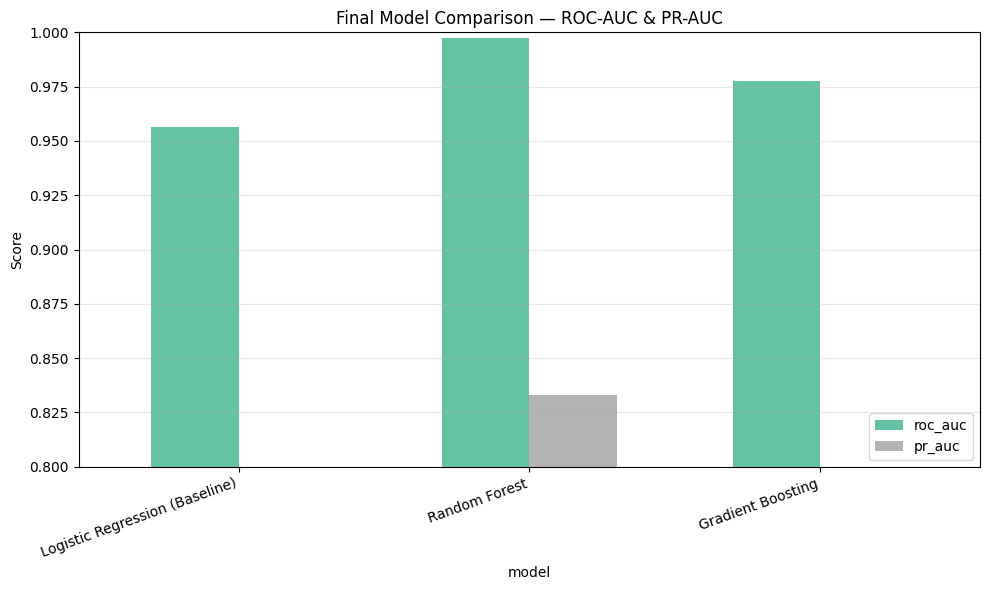

In [41]:
# Final bar chart - main models only
main_results = pd.DataFrame([
    strip(lr_results),
    strip(rf_results),
    strip(xgb_results)
]).set_index('model')[['roc_auc', 'pr_auc']]

main_results.plot(kind='bar', figsize=(10, 6), colormap='Set2', width=0.6)
plt.title('Final Model Comparison — ROC-AUC & PR-AUC')
plt.ylabel('Score')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
